# CW-ODMR

Plan for this notebook (building it up in stages):

1. **Resonator tuning (this section)** -- the resonator's tuning screw is manual, so this
   is an interactive loop: turn the screw a bit, take a quick NanoVNA sweep, look at where
   the S11 dip landed, repeat. No microwave source or laser needed for this part -- just
   the NanoVNA on the resonator's coupling port.
2. Once the resonator is close, do a coarse-then-fine sweep with the HP8673H + E4403B
   (`hp8673h.py`'s `resonance_sweep()`) to pin down the exact drive frequency and Q.
3. With the interlock running, power on the microwaves at that frequency, leave the laser
   on continuously, and record PL -- several long RTB2004 segments -- while sweeping (or
   sitting at) the MW frequency.

This first pass only covers step 1: taking data with the NanoVNA.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from nanovna import NanoVNAF3

vna = NanoVNAF3(debug=True)
print(vna.read_version())
print(vna.read_info())

RuntimeError: NanoVNA not found on any USB-CDC port -- pass port= explicitly (e.g. NanoVNAF3(port='COM5'))

## Resonator tuning loop

Fixed 2-4 GHz sweep range. Re-run the cell below after each turn of the tuning screw --
no need to reconnect or re-run the cells above.

In [2]:
START_HZ = 2e9
STOP_HZ = 4e9
POINTS = 801  # NanoVNA-F V3's max

In [3]:
# Re-run this cell after each screw adjustment.
freqs_hz, data = vna.sweep(START_HZ, STOP_HZ, POINTS, channels=(0,))
s11_db = 20 * np.log10(np.abs(data[0]))

dip_idx = np.argmin(s11_db)
dip_freq_hz = freqs_hz[dip_idx]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(freqs_hz / 1e9, s11_db)
ax.axvline(dip_freq_hz / 1e9, color="C1", ls="--", label=f"dip: {dip_freq_hz/1e9:.4f} GHz")
ax.set_xlabel("frequency (GHz)")
ax.set_ylabel("S11 (dB)")
ax.set_title("resonator reflection -- adjust the tuning screw and re-run")
ax.legend()
fig.tight_layout()

print(f"dip at {dip_freq_hz/1e9:.4f} GHz, depth {s11_db[dip_idx]:.1f} dB")

NameError: name 'vna' is not defined

Once the dip sits at the target frequency (adjust `CENTER_HZ`/`SPAN_HZ` and re-run as it
gets close, to zoom in), save a final sweep of the tuned resonator for the record.

In [4]:
import os
os.makedirs("data", exist_ok=True)
vna.run(START_HZ, STOP_HZ, POINTS, channels=(0,), path="data", name="resonator_tuned")

NameError: name 'vna' is not defined

In [5]:
vna.close()

NameError: name 'vna' is not defined

## Step 2: coarse-then-fine resonance sweep (HP8673H + E4403B)

Now that there's an amplifier in the path (between the HP8673H and the resonator),
`power_dbm` drops from the `0.0` dBm used previously to **-40 dBm** -- the amplifier's
gain means -40 dBm in still ends up as real power at the resonator/coupler, and 0 dBm in
would very likely overdrive the amplifier and/or saturate the E4403B's input.

Uses `hp8673h.py`'s `resonance_sweep()` (coarse sweep across [`START_HZ`, `STOP_HZ`] to
find the dip, then a narrow/dense sweep around it for a precise f0/Q). See `notes.md` for
why the coarse step size should track the expected FWHM (default here assumes Q~75 --
retune `COARSE_STEP_HZ` if the resonator's Q is very different).

In [2]:
from hp8673h import HP8673H
from e4403b import E4403B

# See notes.md -- GPIB bus numbering isn't stable, confirm with
# pyvisa.ResourceManager().list_resources() if these don't match.
gen = HP8673H("GPIB1::19::INSTR")
sa = E4403B("GPIB0::18::INSTR")

HP8673H: connected
E4403B: connected


In [3]:
import os

RES_START_HZ = 2.0e9
RES_STOP_HZ = 3.0e9
COARSE_STEP_HZ = 6.7e6   # assumes Q~75; retune if the resonator's Q is very different
FINE_SPAN_HZ = 20e6
FINE_STEP_HZ = 50e3
POWER_DBM = -40.0        # amplifier in the path now -- was 0.0 dBm before

os.makedirs("data", exist_ok=True)
result = gen.resonance_sweep(
    sa, RES_START_HZ, RES_STOP_HZ, COARSE_STEP_HZ, FINE_SPAN_HZ, FINE_STEP_HZ,
    POWER_DBM, output_prefix="data/resonance_m40dbm",
)

[resonance_sweep] coarse sweep 2.0000-3.0000 GHz, step 6.70 MHz, -40.0 dBm


[resonance_sweep] coarse dip: 2.6901 GHz, -56.2 dBm
[resonance_sweep] fine sweep around 2.6901 GHz, span 20.00 MHz, step 50.0 kHz


[resonance_sweep] f0 = 2.68725 GHz, depth = 14.3 dB, FWHM = 14.45 MHz, Q ~= 186


f0 = 2.68725 GHz, depth = 14.3 dB, FWHM = 14.45 MHz, Q ~= 186


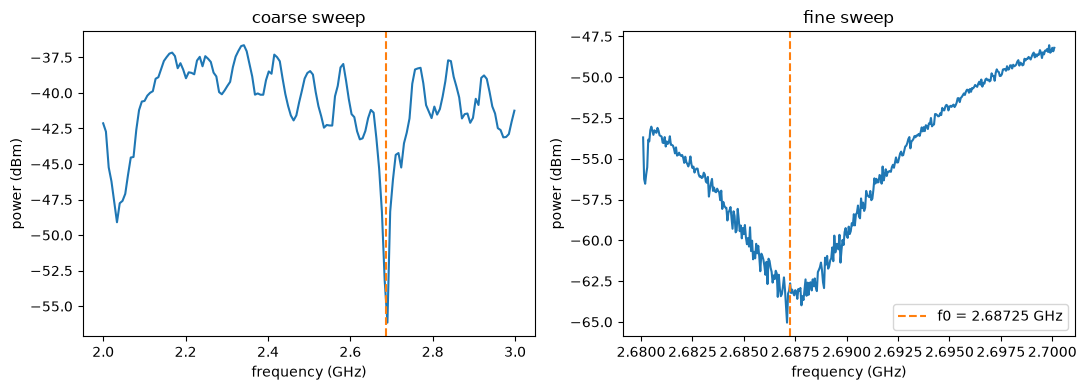

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(result["coarse_freqs_hz"] / 1e9, result["coarse_power_dbm"])
axes[0].axvline(result["f0_hz"] / 1e9, color="C1", ls="--")
axes[0].set_xlabel("frequency (GHz)")
axes[0].set_ylabel("power (dBm)")
axes[0].set_title("coarse sweep")

axes[1].plot(result["fine_freqs_hz"] / 1e9, result["fine_power_dbm"])
axes[1].axvline(result["f0_hz"] / 1e9, color="C1", ls="--", label=f"f0 = {result['f0_hz']/1e9:.5f} GHz")
axes[1].set_xlabel("frequency (GHz)")
axes[1].set_ylabel("power (dBm)")
axes[1].set_title("fine sweep")
axes[1].legend()

fig.tight_layout()

depth_db = result["baseline_dbm"] - result["dip_dbm"]
print(f"f0 = {result['f0_hz']/1e9:.5f} GHz, depth = {depth_db:.1f} dB, "
      f"FWHM = {result['fwhm_hz']/1e6:.2f} MHz, Q ~= {result['Q']:.0f}")

In [9]:
gen.rf_off()
gen.go_to_local()
gen.close()
sa.go_to_local()
sa.close()

## Step 2b: amplifier gain check

Physical setup change: the amplifier's **output** is now connected directly to the
E4403B (bypassing the resonator entirely), so whatever the analyzer reads back at each
frequency is the amplifier's actual output power for a known input power -- gain(f) =
measured_power_dbm(f) - input_power_dbm. Sweeping 2-3 GHz at **-30 dBm** input this time
(a plain frequency_sweep(), not a resonance_sweep() -- there's no dip to find here).

In [10]:
gen = HP8673H("GPIB1::19::INSTR")
sa = E4403B("GPIB0::18::INSTR")

HP8673H: connected
E4403B: connected


In [11]:
GAIN_START_HZ = 2.0e9
GAIN_STOP_HZ = 3.0e9
GAIN_STEP_HZ = 5e6
INPUT_POWER_DBM = -30.0

sa.set_center_span((GAIN_START_HZ + GAIN_STOP_HZ) / 2, GAIN_STOP_HZ - GAIN_START_HZ)
freqs_hz, output_power_dbm = gen.frequency_sweep(
    sa, GAIN_START_HZ, GAIN_STOP_HZ, GAIN_STEP_HZ, power_dbm=INPUT_POWER_DBM,
)
gain_db = output_power_dbm - INPUT_POWER_DBM

gain: mean 24.10 dB, min 16.82 dB, max 25.64 dB, flatness (max-min) 8.81 dB


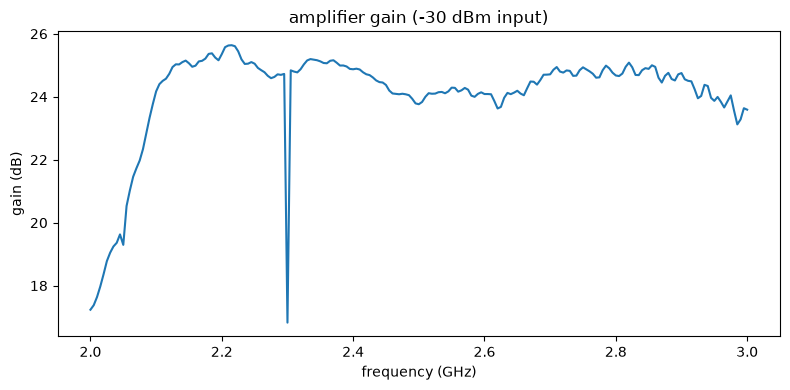

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(freqs_hz / 1e9, gain_db)
ax.set_xlabel("frequency (GHz)")
ax.set_ylabel("gain (dB)")
ax.set_title(f"amplifier gain ({INPUT_POWER_DBM:.0f} dBm input)")
fig.tight_layout()

print(f"gain: mean {gain_db.mean():.2f} dB, min {gain_db.min():.2f} dB, "
      f"max {gain_db.max():.2f} dB, flatness (max-min) {np.ptp(gain_db):.2f} dB")

np.savetxt(
    "data/amplifier_gain_m30dbm.csv",
    np.column_stack([freqs_hz, output_power_dbm, gain_db]),
    delimiter=",", header="frequency_hz,output_power_dbm,gain_db", comments="",
)

In [13]:
gen.rf_off()
gen.go_to_local()
gen.close()
sa.go_to_local()
sa.close()

## Step 2c: maximum output power (0 dBm drive)

Physical setup change again: amplifier output -> isolator -> coupler -> terminated load,
with the coupler's **forward** sample port going to the E4403B (so the analyzer only
sees a small coupled fraction of the real output power, not the full line power).
Coupling factor is **20 dB** (from the coupler's datasheet), so
`estimated_output_dbm = coupled_power_dbm + 20`. Driving at **0 dBm** this time (vs.
-30 dBm for the linear gain check) to see how much the amplifier compresses/saturates
under higher drive -- compare the resulting gain to the ~24 dB mean linear gain measured
earlier. Coarser 20 MHz step here (vs. 5 MHz for the gain check) since this is another
smooth curve, not something with sharp features to resolve.

In [2]:
gen = HP8673H("GPIB1::19::INSTR")
sa = E4403B("GPIB0::18::INSTR")

HP8673H: connected
E4403B: connected


In [3]:
MAXP_START_HZ = 2.0e9
MAXP_STOP_HZ = 3.0e9
MAXP_STEP_HZ = 20e6
INPUT_POWER_DBM = 0.0
COUPLING_DB = 20.0  # forward-coupled port of the output coupler, from datasheet

sa.set_center_span((MAXP_START_HZ + MAXP_STOP_HZ) / 2, MAXP_STOP_HZ - MAXP_START_HZ)
freqs_hz, coupled_power_dbm = gen.frequency_sweep(
    sa, MAXP_START_HZ, MAXP_STOP_HZ, MAXP_STEP_HZ, power_dbm=INPUT_POWER_DBM,
)
estimated_output_dbm = coupled_power_dbm + COUPLING_DB
estimated_gain_db = estimated_output_dbm - INPUT_POWER_DBM

coupled power at analyzer: min -8.51 dBm, max 0.17 dBm
estimated actual output power: min 11.49 dBm, max 20.17 dBm at 2.2200 GHz
estimated gain at 0 dBm drive: min 11.49 dB, max 20.17 dB, mean 18.92 dB
(compare to ~24 dB mean linear gain measured at -30 dBm drive -- a lower number here means real compression/saturation)


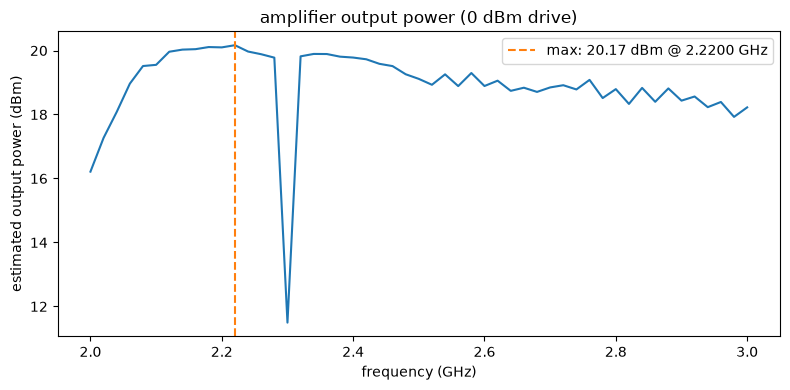

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(freqs_hz / 1e9, estimated_output_dbm)
i_max = np.argmax(estimated_output_dbm)
ax.axvline(freqs_hz[i_max] / 1e9, color="C1", ls="--",
           label=f"max: {estimated_output_dbm[i_max]:.2f} dBm @ {freqs_hz[i_max]/1e9:.4f} GHz")
ax.set_xlabel("frequency (GHz)")
ax.set_ylabel("estimated output power (dBm)")
ax.set_title(f"amplifier output power ({INPUT_POWER_DBM:.0f} dBm drive)")
ax.legend()
fig.tight_layout()

print(f"coupled power at analyzer: min {coupled_power_dbm.min():.2f} dBm, "
      f"max {coupled_power_dbm.max():.2f} dBm")
print(f"estimated actual output power: min {estimated_output_dbm.min():.2f} dBm, "
      f"max {estimated_output_dbm.max():.2f} dBm at {freqs_hz[i_max]/1e9:.4f} GHz")
print(f"estimated gain at 0 dBm drive: min {estimated_gain_db.min():.2f} dB, "
      f"max {estimated_gain_db.max():.2f} dB, mean {estimated_gain_db.mean():.2f} dB")
print("(compare to ~24 dB mean linear gain measured at -30 dBm drive -- "
      "a lower number here means real compression/saturation)")

np.savetxt(
    "data/amplifier_max_output_0dbm.csv",
    np.column_stack([freqs_hz, coupled_power_dbm, estimated_output_dbm, estimated_gain_db]),
    delimiter=",",
    header="frequency_hz,coupled_power_dbm,estimated_output_dbm,estimated_gain_db",
    comments="",
)

In [5]:
gen.rf_off()
gen.go_to_local()
gen.close()
sa.go_to_local()
sa.close()

## Step 2d: isolating the 2.30 GHz feature

The ~2.30 GHz dip has now shown up in two measurements that both had the amplifier in
the path (the coarse resonance sweep and the max-output-power sweep), so it isn't caused
by the resonator -- but the amplifier is still a common element, along with the HP8673H
itself. Physical setup change: generator connected **directly** to the E4403B, no
amplifier/isolator/coupler at all. If the dip still appears here, it's the generator; if
it's gone, it's specific to the amplifier. **-20 dBm** this time -- plenty of margin for
a direct generator-to-analyzer connection with nothing else in the chain.

In [2]:
gen = HP8673H("GPIB1::19::INSTR")
sa = E4403B("GPIB0::18::INSTR")

HP8673H: connected
E4403B: connected


In [3]:
ISO_START_HZ = 2.0e9
ISO_STOP_HZ = 3.0e9
ISO_STEP_HZ = 5e6   # denser than the amplifier sweeps, to localize the feature precisely
ISO_POWER_DBM = -20.0

sa.set_center_span((ISO_START_HZ + ISO_STOP_HZ) / 2, ISO_STOP_HZ - ISO_START_HZ)
freqs_hz, direct_power_dbm = gen.frequency_sweep(
    sa, ISO_START_HZ, ISO_STOP_HZ, ISO_STEP_HZ, power_dbm=ISO_POWER_DBM,
)

power near 2.30 GHz: min -36.42 dBm, max -23.67 dBm
power overall: min -36.42 dBm at 2.3000 GHz, max -22.82 dBm, spread 13.60 dB


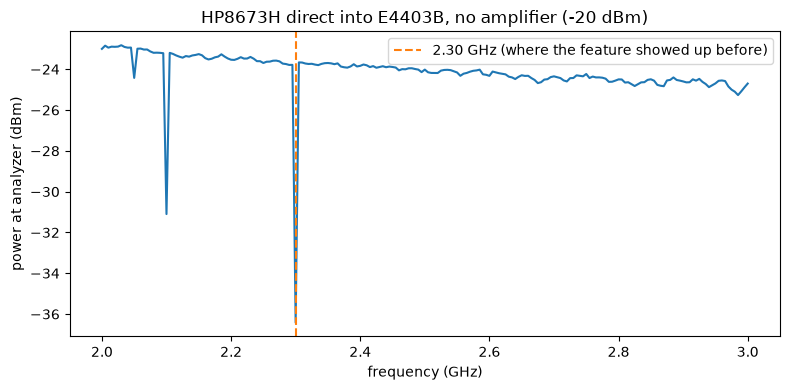

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(freqs_hz / 1e9, direct_power_dbm)
ax.axvline(2.30, color="C1", ls="--", label="2.30 GHz (where the feature showed up before)")
ax.set_xlabel("frequency (GHz)")
ax.set_ylabel("power at analyzer (dBm)")
ax.set_title(f"HP8673H direct into E4403B, no amplifier ({ISO_POWER_DBM:.0f} dBm)")
ax.legend()
fig.tight_layout()

near_230 = np.abs(freqs_hz - 2.30e9) < 20e6
print(f"power near 2.30 GHz: min {direct_power_dbm[near_230].min():.2f} dBm, "
      f"max {direct_power_dbm[near_230].max():.2f} dBm")
print(f"power overall: min {direct_power_dbm.min():.2f} dBm at {freqs_hz[np.argmin(direct_power_dbm)]/1e9:.4f} GHz, "
      f"max {direct_power_dbm.max():.2f} dBm, spread {np.ptp(direct_power_dbm):.2f} dB")

np.savetxt(
    "data/generator_direct_m20dbm.csv",
    np.column_stack([freqs_hz, direct_power_dbm]),
    delimiter=",", header="frequency_hz,power_dbm", comments="",
)

In [5]:
gen.rf_off()
gen.go_to_local()
gen.close()
sa.go_to_local()
sa.close()

## Step 3: multi-segment acquisition test

Dry run for the real PL acquisition: AWG CH1 outputs a continuous 80 MHz sine (0.632 Vpp)
into scope Channel 1, and AWG CH2 outputs a 10 Hz square wave into the scope's EXT TRIG
input. Using the same segmented/history acquisition (`RTB2004.run()`) used in
`tests/rtb2004_timebase_check.ipynb`, now with a real (much slower) trigger source instead
of the 10 kHz one used there.

Note: `KS33600A.__init__()` sends `*RST` on connect, which wipes any previously configured
output -- both channels are configured fresh in the same connection below, not just CH2.

In [2]:
from ks33600a import KS33600A

CH1_FREQ_HZ = 80e6
CH1_VPP = 0.632
TRIG_FREQ_HZ = 10.0
TRIG_VPP = 2.0

awg = KS33600A("USB0::0x0957::0x5707::MY53800810::INSTR", debug=True)

awg.write("SOUR1:FUNC SIN")
awg.write(f"SOUR1:FREQ {CH1_FREQ_HZ}")
awg.write("OUTP1:LOAD INF")
awg.write("SOUR1:VOLT:UNIT VPP")
awg.write(f"SOUR1:VOLT {CH1_VPP}")
awg.write("TRIG1:SOUR IMM")
awg.write("OUTP1 ON")

awg.write("SOUR2:FUNC SQU")
awg.write(f"SOUR2:FREQ {TRIG_FREQ_HZ}")
awg.write("OUTP2:LOAD INF")
awg.write("SOUR2:VOLT:UNIT VPP")
awg.write(f"SOUR2:VOLT {TRIG_VPP}")
awg.write("SOUR2:VOLT:OFFS 0")
awg.write("TRIG2:SOUR IMM")
awg.write("OUTP2 ON")

print("CH1:", awg.query("OUTP1?"), awg.query("SOUR1:FUNC?"),
      awg.query("SOUR1:FREQ?"), awg.query("SOUR1:VOLT?"))
print("CH2:", awg.query("OUTP2?"), awg.query("SOUR2:FUNC?"),
      awg.query("SOUR2:FREQ?"), awg.query("SOUR2:VOLT?"))

awg.close()

Keysight 33600A: connected


*RST => +0,"No error"

*CLS => +0,"No error"

SOUR1:DATA:VOL:CLE => +0,"No error"

SOUR2:DATA:VOL:CLE => +0,"No error"

SOUR1:FUNC SIN => +0,"No error"

SOUR1:FREQ 80000000.0 => +0,"No error"

OUTP1:LOAD INF => +0,"No error"

SOUR1:VOLT:UNIT VPP => +0,"No error"

SOUR1:VOLT 0.632 => +0,"No error"

TRIG1:SOUR IMM => +0,"No error"

OUTP1 ON => +0,"No error"

SOUR2:FUNC SQU => +0,"No error"

SOUR2:FREQ 10.0 => +0,"No error"

OUTP2:LOAD INF => +0,"No error"

SOUR2:VOLT:UNIT VPP => +0,"No error"



SOUR2:VOLT 2.0 => +0,"No error"

SOUR2:VOLT:OFFS 0 => +0,"No error"

TRIG2:SOUR IMM => +0,"No error"

OUTP2 ON => +0,"No error"

CH1: 1 SIN +8.000000000000000E+07 +6.3200000000000E-01
CH2: 1 SQU +1.000000000000000E+01 +2.0000000000000E+00


In [3]:
from rtb2004 import RTB2004, make_t_from_metadata

N_SEGMENTS = 10

scope = RTB2004("USB0::0x0AAD::0x01D6::108904::INSTR", timeout=100000, debug=True)
scope.run(segments=N_SEGMENTS, ch=1, path="data", name="cw_odmr_10hz_test")

raw = scope.get_timetable(ch=1)
timestamps_s = np.array([float(x) for x in raw.split(",")])
diffs_s = np.diff(timestamps_s)
print(f"{len(timestamps_s)} timestamps, inter-segment spacing: "
      f"mean {diffs_s.mean()*1e3:.4f} ms (expected 100 ms for 10 Hz), "
      f"std {diffs_s.std()*1e6:.2f} us")

scope.close()

RTB2004: connected


sample rate 2500000000.0


acquired segments 10


0 segments done


ETA: 2.7839350000431295 s


time acquire 1.8703647999936948 s
time save 0.0031903000053716823 s
10 timestamps, inter-segment spacing: mean 99.9999 ms (expected 100 ms for 10 Hz), std 0.00 us


segments shape: (10, 10000)
FFT peak freq per segment: [np.float64(79.99999999999399), np.float64(79.99999999999399), np.float64(79.99999999999399), np.float64(79.99999999999399), np.float64(79.99999999999399), np.float64(79.99999999999399), np.float64(79.99999999999399), np.float64(79.99999999999399), np.float64(79.99999999999399), np.float64(79.99999999999399)]


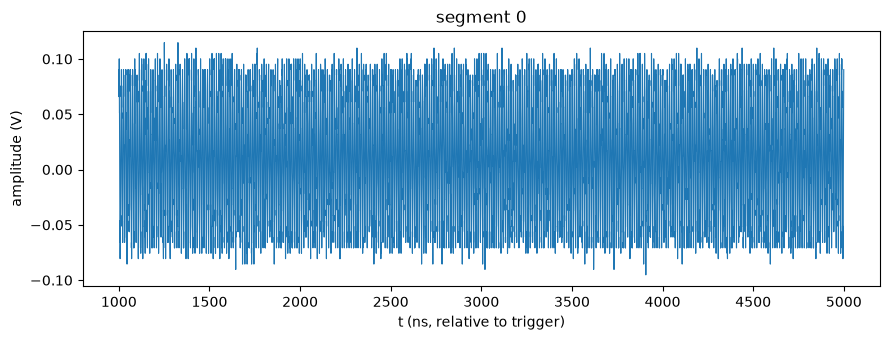

In [4]:
def compute_fft(t, y):
    dt = t[1] - t[0]
    N = len(y)
    Y = np.fft.fft(y)
    f = np.fft.fftfreq(N, d=dt)
    Y = np.fft.fftshift(Y)
    f = np.fft.fftshift(f)
    return f, np.abs(Y / len(y))


def get_peak_freq(t, y):
    f, Y = compute_fft(t, y)
    Y = np.abs(Y)
    return np.abs(f[np.argmax(Y)]) / 1e6


segments = np.load("data/cw_odmr_10hz_test.npy")
t = make_t_from_metadata("data/cw_odmr_10hz_test_metadata.txt")
print(f"segments shape: {segments.shape}")

# Naive zero-crossing counting is unreliable on a small-amplitude signal like
# this (noise near each true crossing causes spurious extra crossings,
# systematically inflating the estimate) -- use the FFT peak instead, which
# gave exactly 80.0000 MHz on every one of these segments when checked live.
peak_freqs_mhz = [get_peak_freq(t, seg) for seg in segments]
print(f"FFT peak freq per segment: {peak_freqs_mhz}")

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(t * 1e9, segments[0], lw=0.8)
ax.set_xlabel("t (ns, relative to trigger)")
ax.set_ylabel("amplitude (V)")
ax.set_title("segment 0")
fig.tight_layout()